# 1. Import & Config

In [1]:
import sys, os, json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from scipy.stats import gaussian_kde

from config import InferenceConfig, DDPMTransformerConfig
from utils import setup_logging, setup_random_seed, load_variant, inverse_x
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR

logger = setup_logging()
logger.info("✓ Imports OK")

2026-05-28 02:26:55,902 - utils.setup - INFO - Logger is set up.
2026-05-28 02:26:55,904 - utils.setup - INFO - ✓ Imports OK


## 1.1 Config

In [2]:
inf_cfg = InferenceConfig(
    name              = "v3_portfolio_01",
    group             = "",
    description       = "Portfolio analysis from simulation outputs",

    processed_dir     = Path(PROCESSED_DIR),
    experiments_dir   = Path(EXPERIMENTS_DIR),

    experiment_name   = "v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard",
    simulation_name   = "demo_sim_01",
    checkpoint_file   = "epoch_1000.pt",

    num_simulations   = 100,
    random_seed       = 42,
)

setup_random_seed(inf_cfg.random_seed)

print("=" * 60)
print("  V3-4 PORTFOLIO")
print("=" * 60)
print(f"  Experiment      : {inf_cfg.experiment_name}")
print(f"  Simulation      : {inf_cfg.simulation_name}")
print(f"  Simulation dir  : {inf_cfg.simulation_dir}")
print("=" * 60)

  V3-4 PORTFOLIO
  Experiment      : v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard
  Simulation      : demo_sim_01
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/simulations/demo_sim_01


# 2. Load Simulation Data

## 2.1 SimulationDataset

โหลดจาก `.npz` ที่ save ไว้ใน `sim_dir` ของ V3-3  
แต่ละ file = 1 test window ประกอบด้วย:

| key | shape | description |
|---|---|---|
| `x_gen` | `(N, A, W, D, C)` | generated log-returns (N sims) |
| `x_real` | `(A, W, D, C)` | real log-returns |
| `log_returns` | `(N, A, W, C)` | decoded log-returns |
| `prices` | `(N, A, W, C)` | decoded prices |
| `init_price` | `(A,)` | initial price ของ window |
| `dates` | `(W,)` | timestamps ของแต่ละ window step |
| `init_date` | scalar | timestamp เริ่มต้น window |
| `ohlcv` | `(A, W, D, C)` | raw OHLCV real data |

In [3]:
class SimulationDataset(Dataset):
    def __init__(self, sim_dir: Path):
        self.sim_dir = Path(sim_dir)
        with open(self.sim_dir / "meta.json") as f:
            self.meta = json.load(f)
        self.n = self.meta["n_windows"]

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        raw = np.load(self.sim_dir / f"batch_{idx:03d}.npz")
        return {k: raw[k] for k in raw.files}

    def __repr__(self):
        return (f"SimulationDataset(n_windows={self.n}, "
                f"n_sims={self.meta['num_simulations']}, "
                f"symbols={len(self.meta['symbols'])})")

## 2.2 Load & Inspect

In [4]:
sim_dir = inf_cfg.simulation_dir
dataset = SimulationDataset(sim_dir)
print(dataset)

# meta summary
meta = dataset.meta
SYMBOLS     = meta["symbols"]
N_SIMS      = meta["num_simulations"]
N_WINDOWS   = meta["n_windows"]
N_ASSETS    = len(SYMBOLS)

print(f"\n  symbols      : {SYMBOLS}")
print(f"  n_windows    : {N_WINDOWS}")
print(f"  n_sims       : {N_SIMS}")
print(f"  created_at   : {meta['created_at']}")

SimulationDataset(n_windows=1, n_sims=100, symbols=16)

  symbols      : ['AAPL', 'AMZN', 'CAT', 'EEM', 'GOOGL', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'SPY', 'TLT', 'TSLA', 'GLD', 'XOM']
  n_windows    : 1
  n_sims       : 100
  created_at   : 2026-05-27T04:16:18.686085+00:00


## 2.3 Shape Check

In [5]:
# peek at first window
sample = dataset[0]

print(f"{'key':<16} {'shape':<30} dtype")
print("─" * 60)
for k, v in sample.items():
    arr = np.array(v)
    print(f"  {k:<14} {str(arr.shape):<30} {arr.dtype}")

key              shape                          dtype
────────────────────────────────────────────────────────────
  x_gen          (100, 16, 20, 20, 4)           float32
  x_real         (16, 20, 20, 4)                float32
  cond           (16, 20, 11)                   float32
  init_price     (16,)                          float32
  init_date      ()                             int64
  dates          (20,)                          int64
  ohlcv          (16, 20, 4)                    float32
  log_returns    (100, 16, 20, 20, 4)           float32
  prices         (100, 16, 20, 20)              float32


## 2.4 Load All Windows into Memory

In [6]:
# โหลดทั้งหมดเข้า memory (สะดวกถ้า dataset ไม่ใหญ่มาก)
# ถ้า dataset ใหญ่ → ใช้ DataLoader แทน

all_windows = [dataset[i] for i in range(N_WINDOWS)]
print(f"  ✓ loaded {len(all_windows)} windows")

# ── ตัวอย่าง: ใช้ DataLoader ─────────────────────────────────────────
# loader = DataLoader(dataset, batch_size=1, shuffle=False)
# for batch in loader:
#     x_gen      = batch["x_gen"]      # (1, N, A, W, D, C)
#     prices     = batch["prices"]     # (1, N, A, W, C)
#     init_price = batch["init_price"] # (1, A)
#     ...

# ── ตัวอย่าง: stack arrays ────────────────────────────────────────────
# prices shape per window: (N, A, W, C) → stack → (T_windows, N, A, W, C)
all_prices     = np.stack([w["prices"]      for w in all_windows])  # (T, N, A, W, C)
all_log_ret    = np.stack([w["log_returns"] for w in all_windows])  # (T, N, A, W, C)
all_init_price = np.stack([w["init_price"]  for w in all_windows])  # (T, A)
all_dates      = np.stack([w["dates"]       for w in all_windows])  # (T, W)

print(f"  all_prices     : {all_prices.shape}")
print(f"  all_log_ret    : {all_log_ret.shape}")
print(f"  all_init_price : {all_init_price.shape}")
print(f"  all_dates      : {all_dates.shape}")

  ✓ loaded 1 windows
  all_prices     : (1, 100, 16, 20, 20)
  all_log_ret    : (1, 100, 16, 20, 20, 4)
  all_init_price : (1, 16)
  all_dates      : (1, 20)


## 2.5 Load Feature Store

In [7]:
feature_name, feature_variant = inf_cfg.load_feature_store_info()
_, scalers = load_variant(inf_cfg.processed_dir, feature_name, feature_variant)
x_scaler = scalers["x"]

print(f"  feature_store : {feature_name} / {feature_variant}")
print(f"  ✓ x_scaler loaded")

  feature_store : v1_trial04_w20_d20_asset16 / robust_standard
  ✓ x_scaler loaded


In [8]:
from entities import Portfolio
from utils import inverse_x

pf = Portfolio(annual_risk_free_rate=0.02)

# step 1: optimize + backtest ทุก window
# window_results = pf.experiment_windows(
#     all_windows=all_windows,
#     rebalance_freq=5,
#     optimize_window=10,
#     asset_names=SYMBOLS,
#     transaction_cost=0.0025,
#     method="Per-Path",
#     x_scaler=x_scaler,
#     inverse_x_fn=inverse_x,
# )



🚀 เริ่มทำการทดลองบนฟังก์ชันที่แก้ไขใหม่...


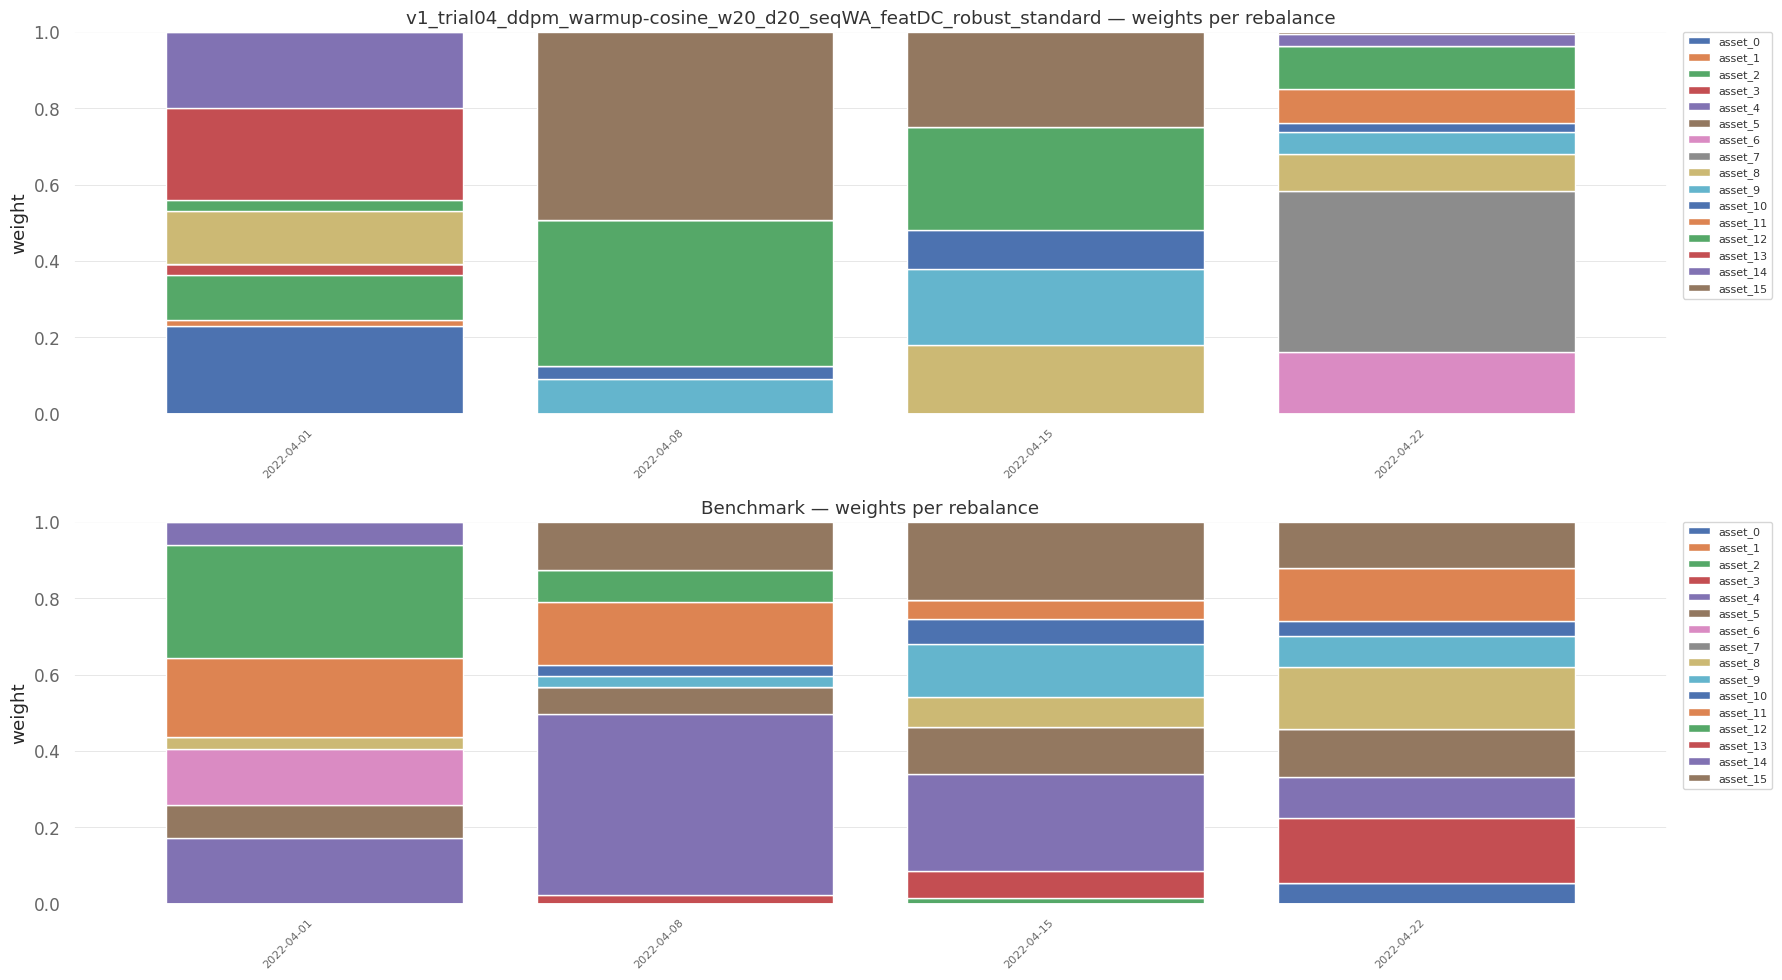

2026-05-28 02:27:44,164 - entities.portfolio - INFO - Strategy: v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard vs Benchmark: Benchmark
2026-05-28 02:27:45,786 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:45,816 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:45,941 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:45,942 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:45,988 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:45,988 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:45,989 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:46,031 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 02:27:46,0

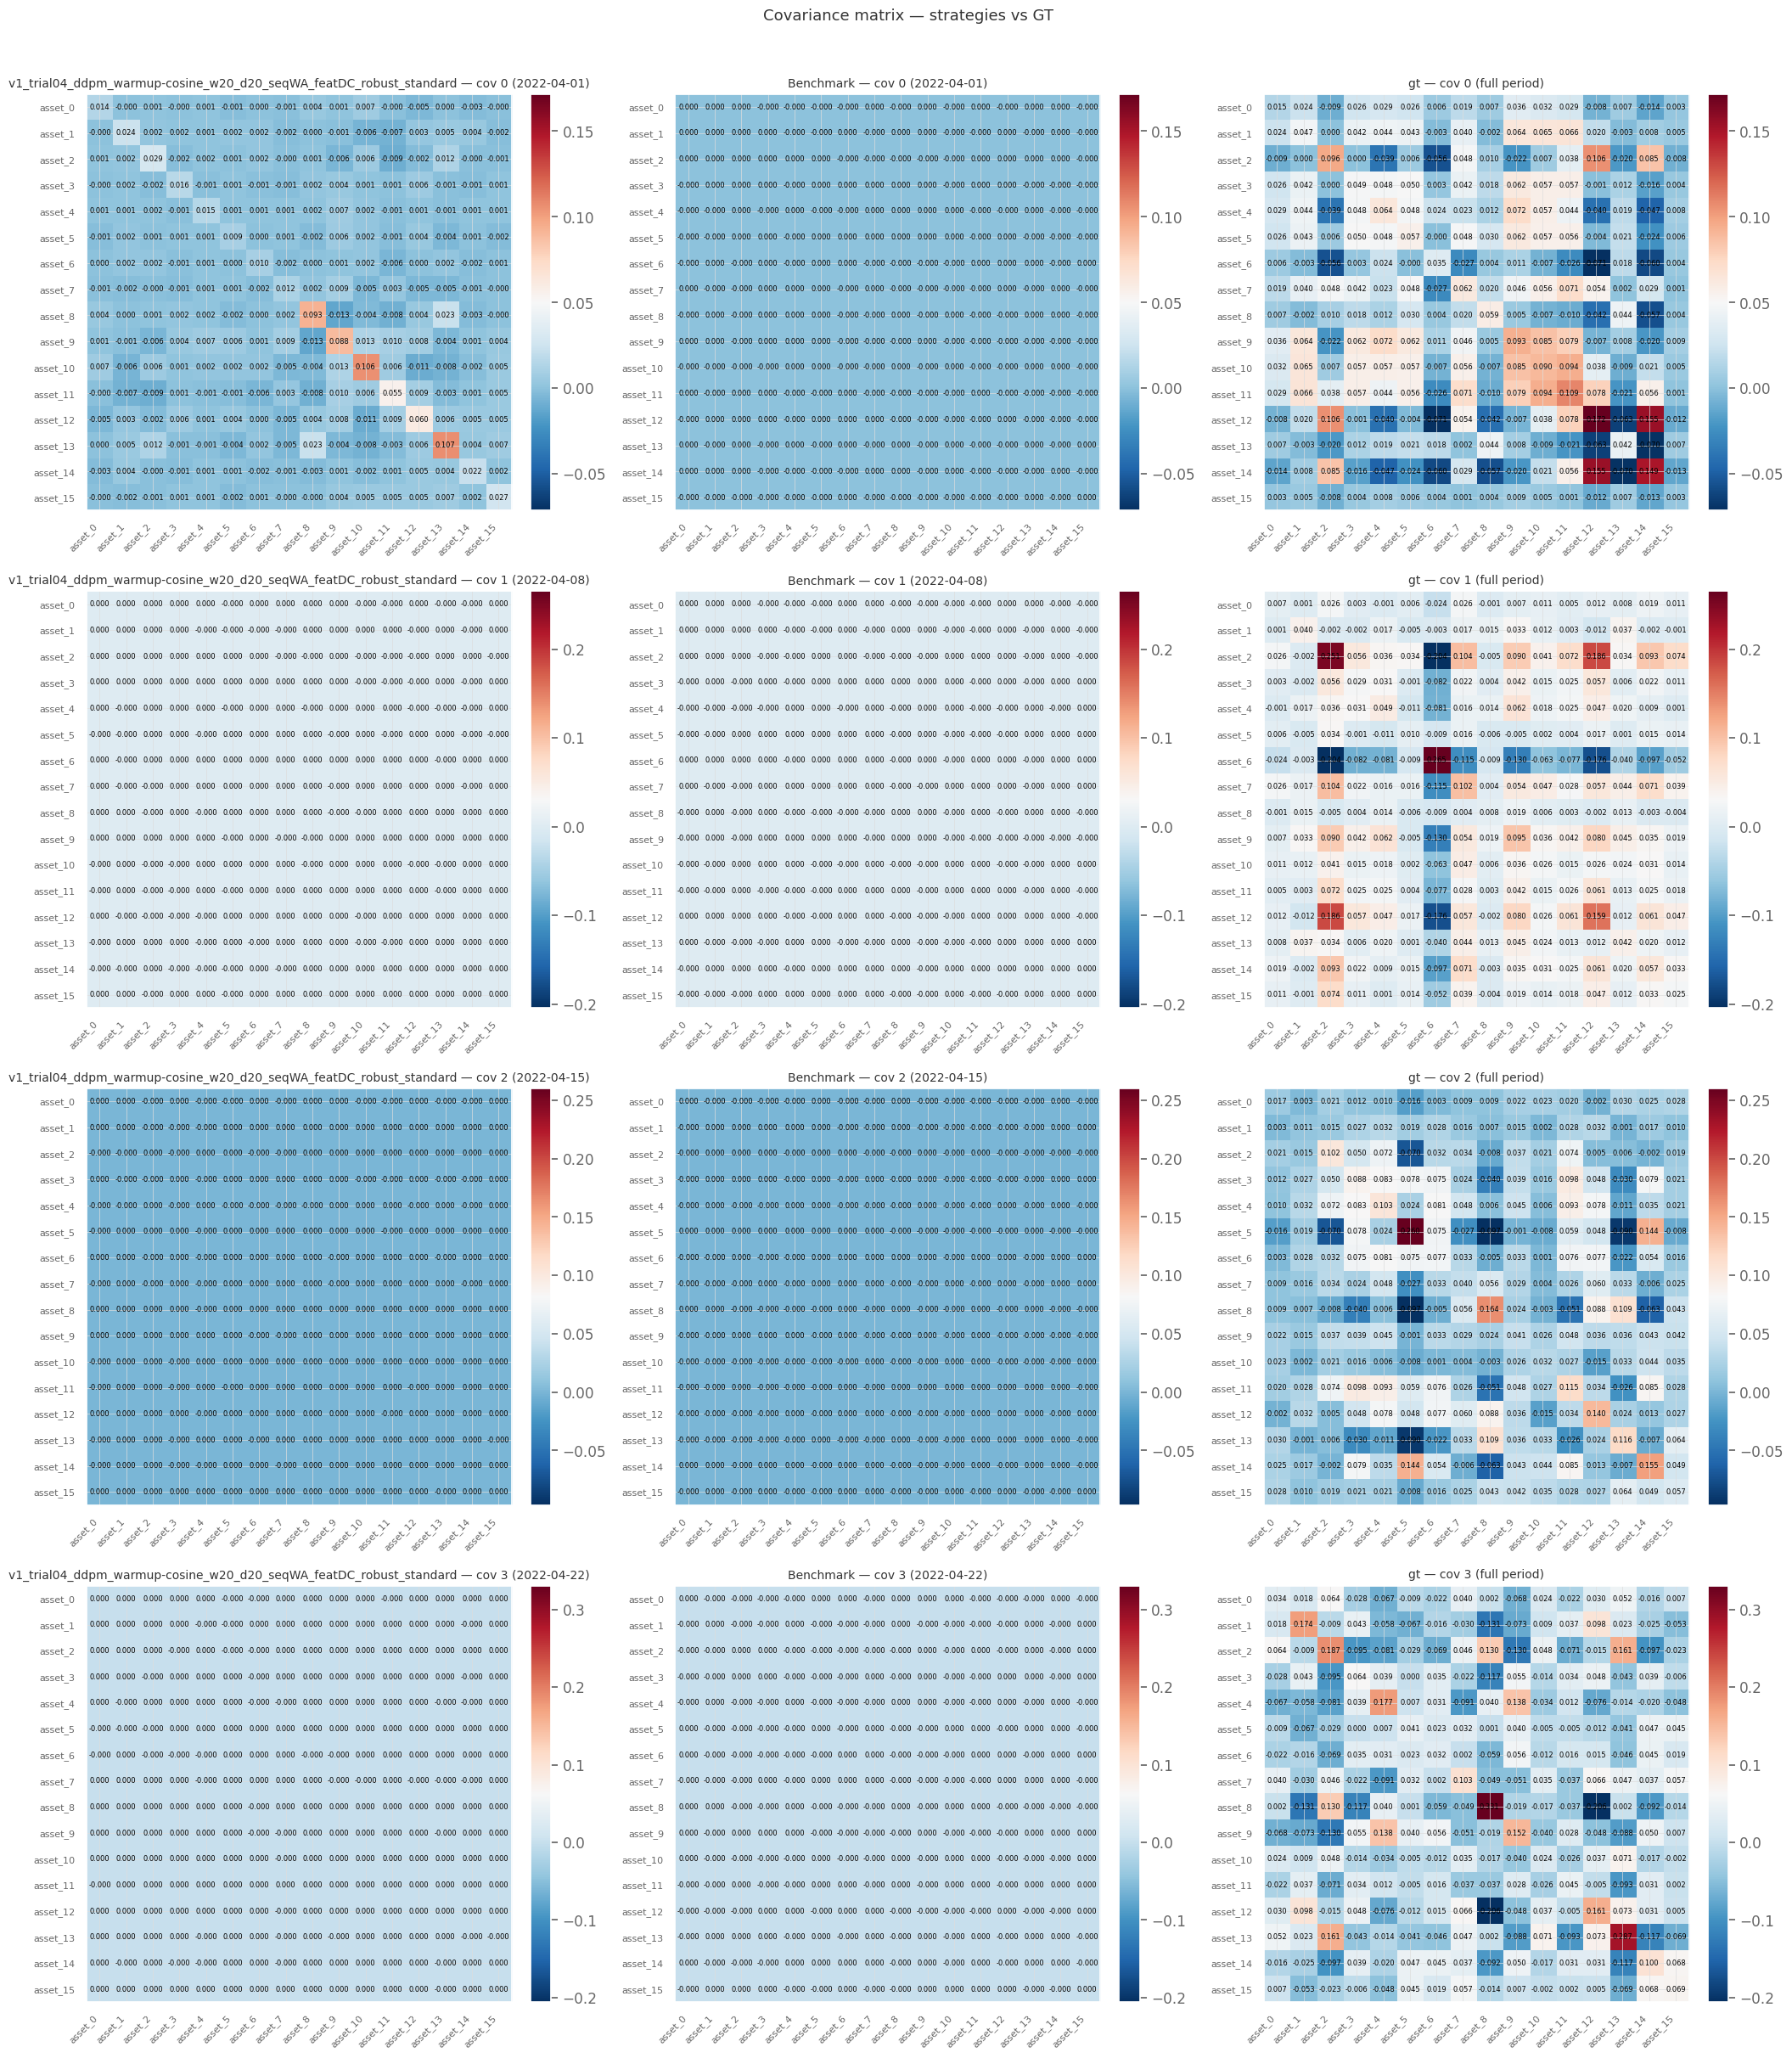

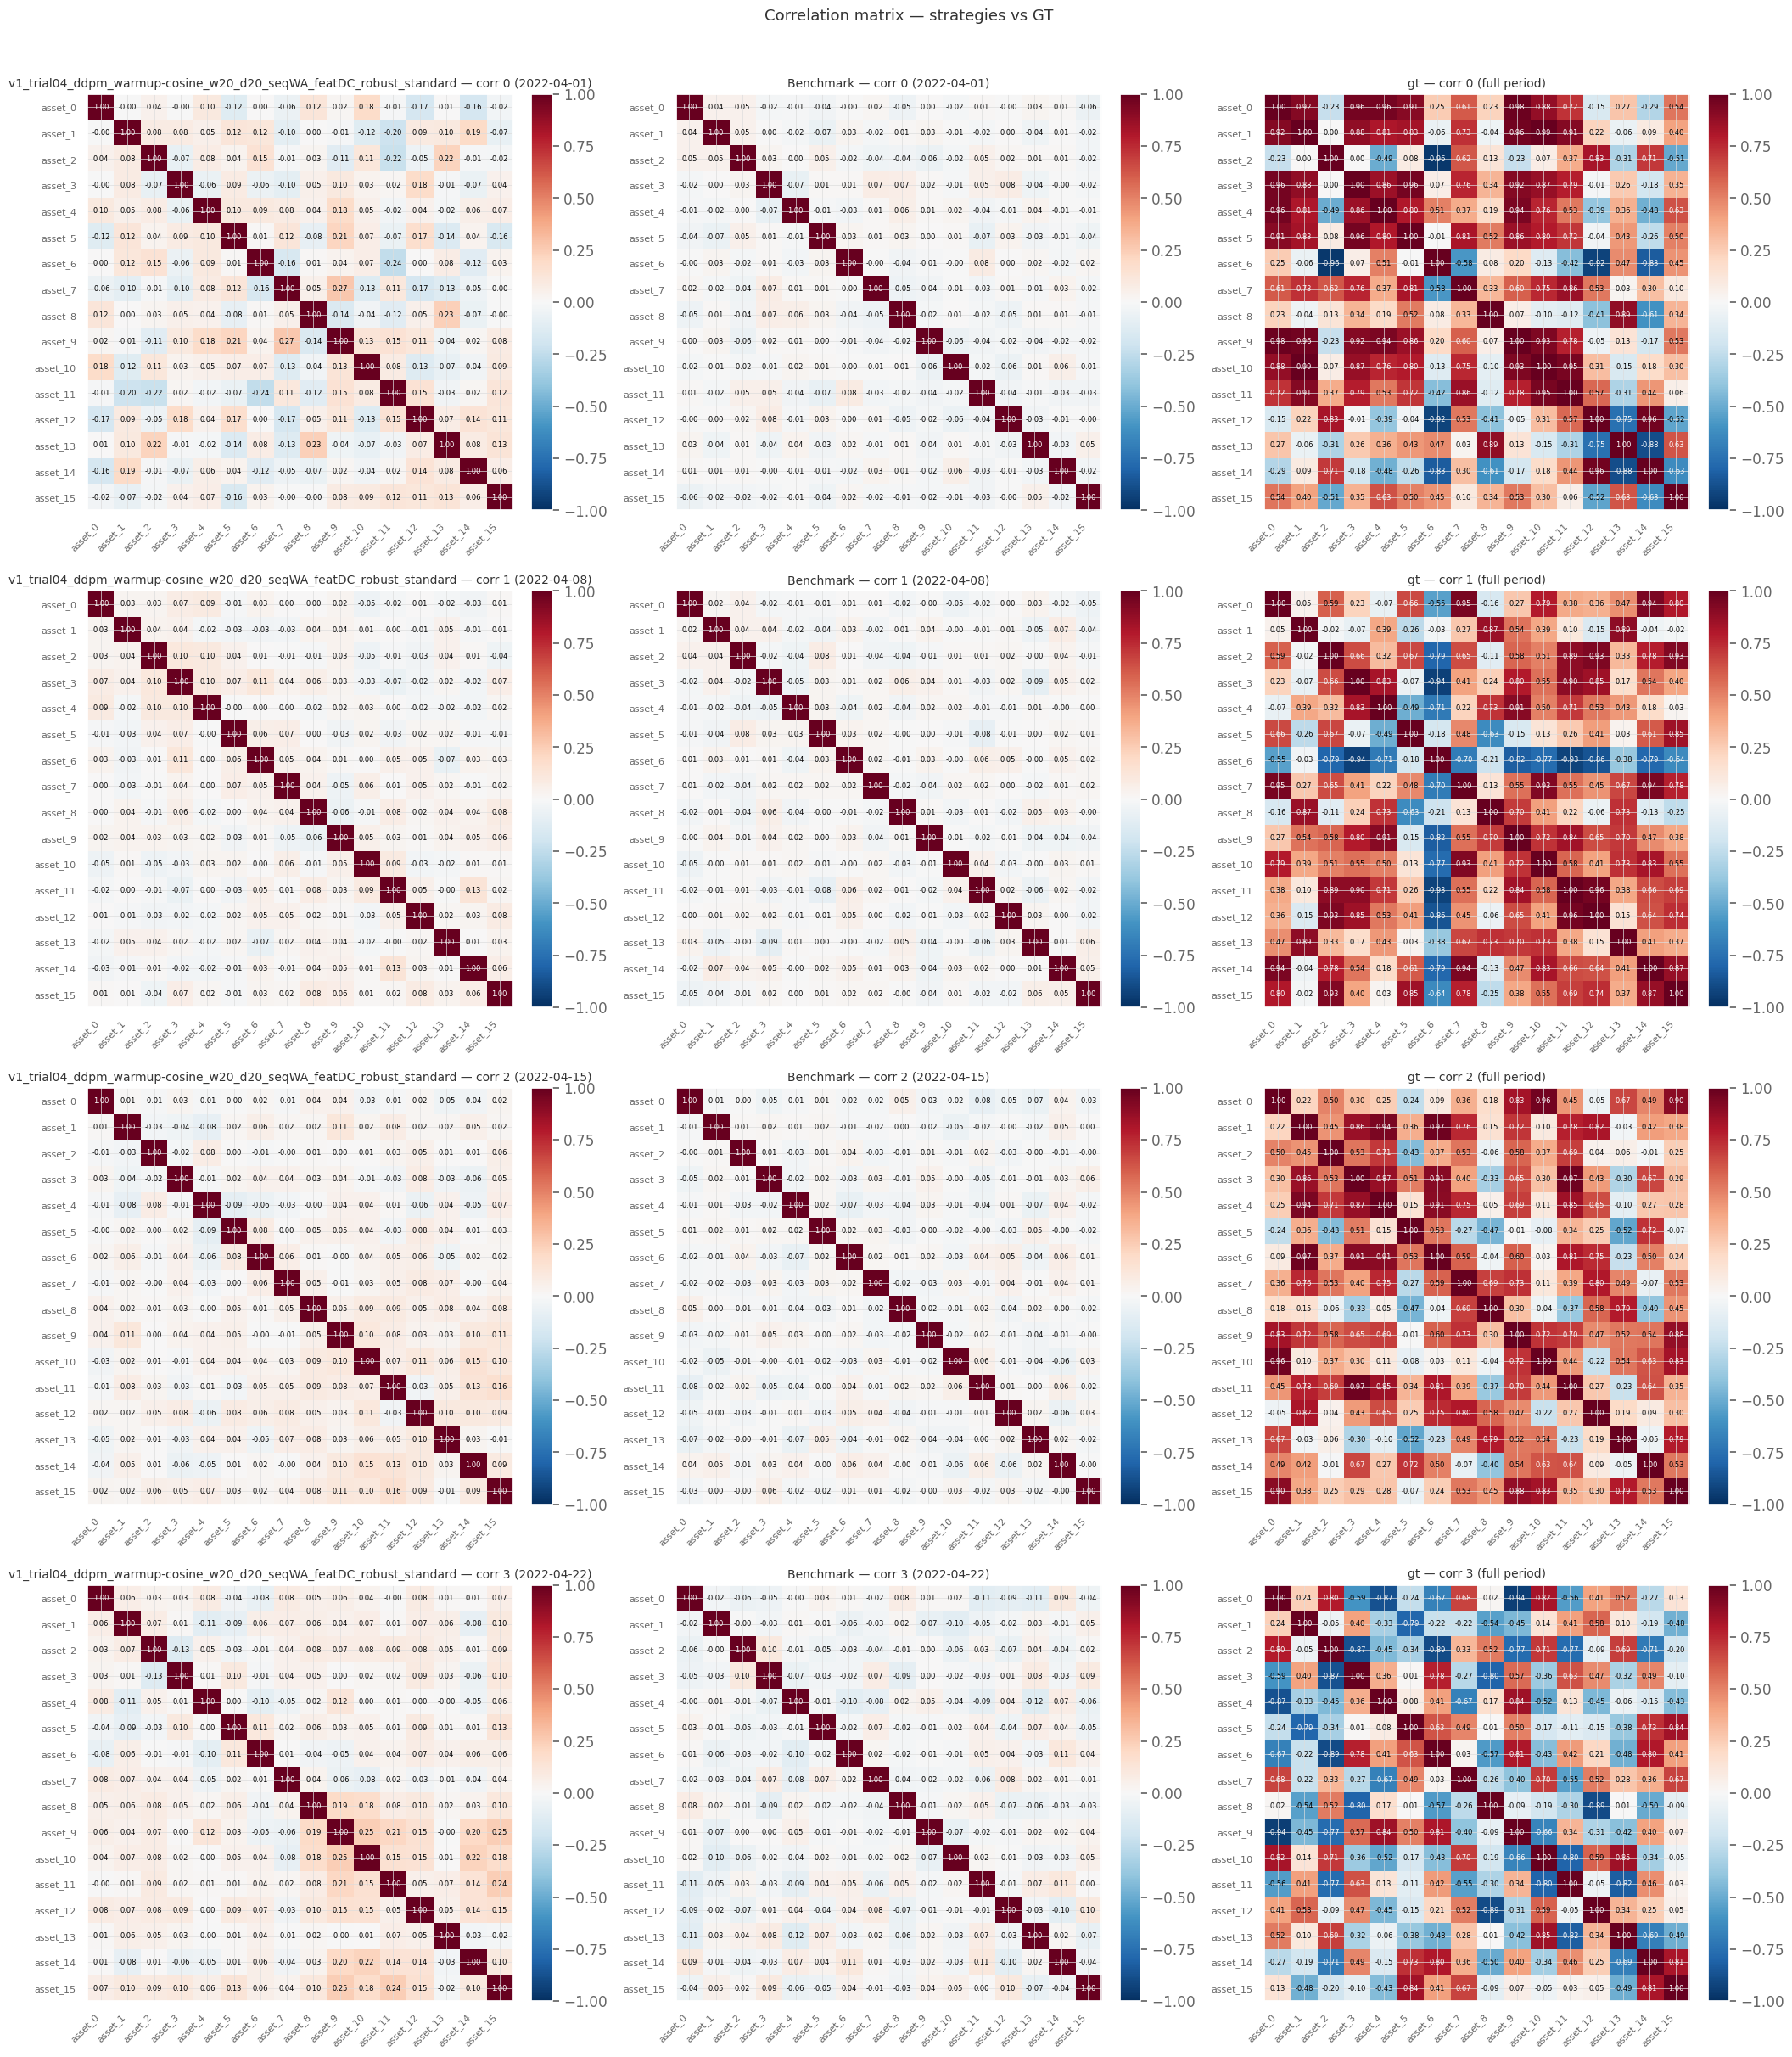

IndexError: list index out of range

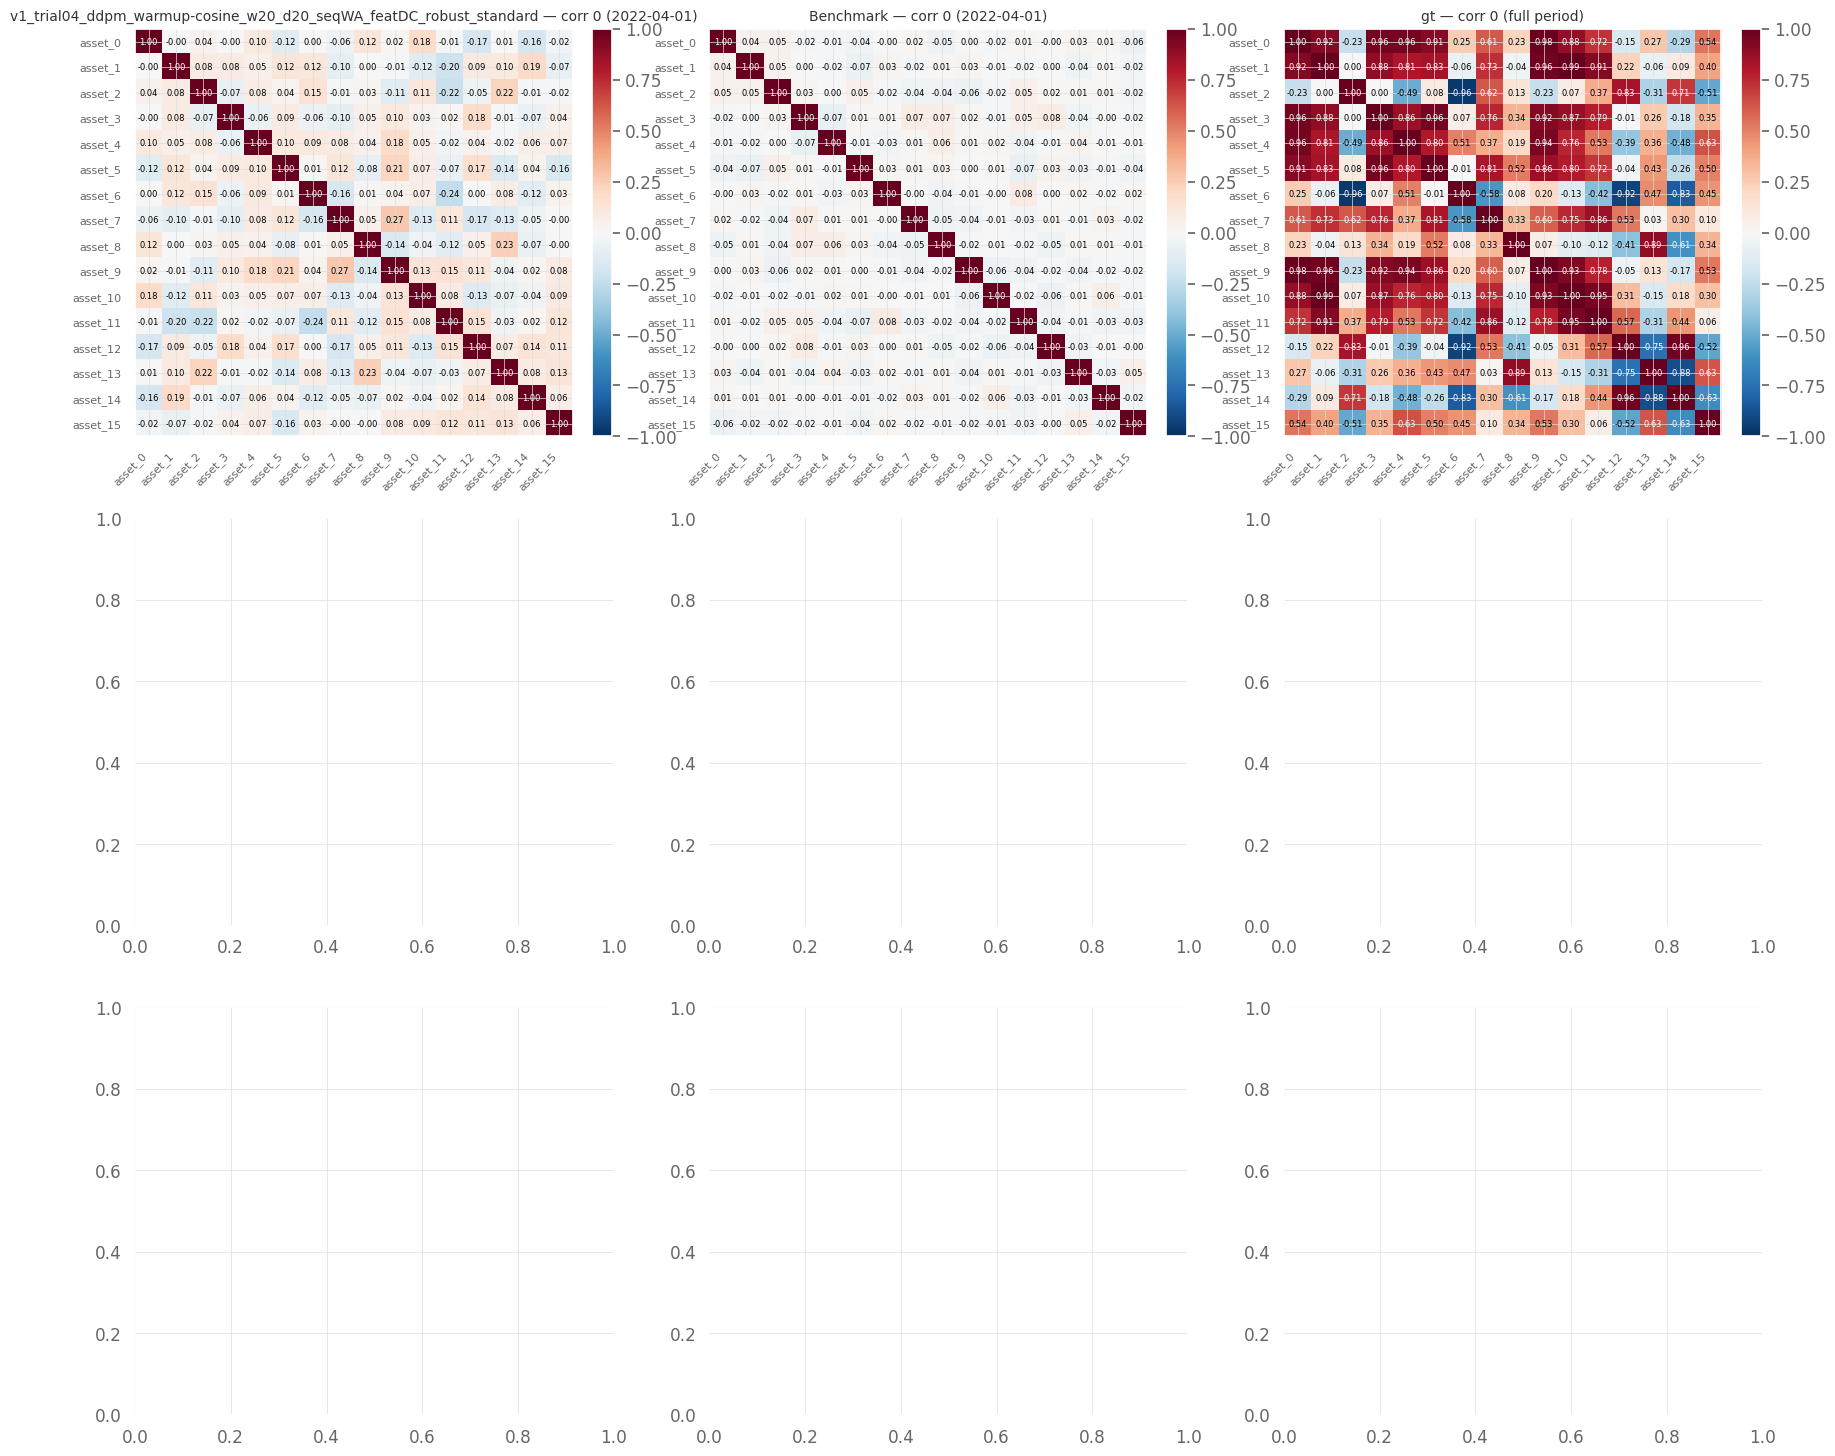

In [9]:
import pandas as pd
import numpy as np

# 1. ดึงข้อมูลจาก Window แรกที่โหลดไว้แล้วในตัวแปร all_windows
sample = all_windows[0]

# --- เตรียมข้อมูล Ground Truth (GT) ---
# ohlcv มี shape: (16, 20, 4) -> (Assets, Time, OHLC)
# ดึงราคาปิด (Close = index 3) แล้วสลับแกนให้เป็น (Time, Assets) -> (20, 16)
gt_prices = sample["ohlcv"][:, :, 3].T

# คำนวณ gt_returns (log return) จาก gt_prices
gt_returns = np.zeros_like(gt_prices)
gt_returns[1:] = np.log(gt_prices[1:] / gt_prices[:-1])

# --- แก้ไขตรงนี้: เปลี่ยน unit เป็น 'ns' ตามฟอร์แมตข้อมูลของคุณ ---
dates_ts = sample["dates"]
dates = [pd.to_datetime(ts, unit='ns').date() for ts in dates_ts]
start_date = dates[0]
end_date = dates[-1]

# --- เตรียมข้อมูล Strategies ---
# log_returns มี shape: (100, 16, 20, 20, 4) -> (N_SIMS, Assets, W, D, OHLC)
# ดึงหน้าต่างย่อยแรกสุด (W=0) และดึงเฉพาะราคาปิด (Close=3)
# จากนั้น Transpose จาก (100, 16, 20) -> (100, 20, 16) เพื่อให้เป็น (n_paths, n_lengths, n_assets)
mc_returns_ddpm = sample["log_returns"][:, :, 0, :, 3].transpose(0, 2, 1)

# สร้าง Benchmark ขึ้นมาเปรียบเทียบ (จำลองสุ่มตัวเลขขนาดเท่ากันขึ้นมา)
mc_returns_bench = np.random.normal(0.0001, 0.01, size=mc_returns_ddpm.shape)

# ใช้ชื่อ Model จาก inf_cfg.experiment_name มาตั้งเป็นชื่อ Strategy
strategies = {
    inf_cfg.experiment_name: mc_returns_ddpm,
    "Benchmark": mc_returns_bench
}

# --- 2. เรียกใช้งาน fn experiment ที่แก้ไขใหม่ ---
print("🚀 เริ่มทำการทดลองบนฟังก์ชันที่แก้ไขใหม่...")

portfolios = pf.experiment(
    gt_returns=gt_returns,
    gt_prices=gt_prices,
    strategies=strategies,
    benchmark_strategy="Benchmark",
    rebalance_freq=5,        # < 20 (ตามเงื่อนไขความยาว D)
    optimize_window=10,      # < 20
    start_date=start_date,
    end_date=end_date,
    transaction_cost=0.0025,
    init_cash=1.0,
    is_log_return=True,
    method="Per-Path",
    output_dir="reports/v3_portfolio_01_exp",
    output_suffix="_test_window0"
)

print("✅ ทดสอบสำเร็จ! สามารถตรวจสอบ Report ราย Window ได้ที่โฟลเดอร์ reports/v3_portfolio_01_exp/")